In [137]:
import pandas as pd
import numpy as np

In [138]:
df = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

df.head()

,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1,143352.0,1.955041,-0.380783,-0.315013,0.330155,-0.509374,-0.086197,-0.627978,0.035994,...,0.238197,0.968305,0.053208,-0.278602,-0.044999,-0.216780,0.045168,-0.047145,9.99,0
1,2,117173.0,-0.400975,-0.626943,1.555339,-2.017772,-0.107769,0.168310,0.017959,-0.401619,...,-0.153485,0.421703,0.113442,-1.004095,-1.176695,0.361924,-0.370469,-0.144792,45.90,0
2,3,149565.0,0.072509,0.820566,-0.561351,-0.709897,1.080399,-0.359429,0.787858,0.117276,...,-0.314638,-0.872959,0.083391,0.148178,-0.431459,0.119690,0.206395,0.070288,11.99,0
3,4,93670.0,-0.535045,1.014587,1.750679,2.769390,0.500089,1.002270,0.847902,-0.081323,...,0.063525,0.443431,-0.072754,0.448192,-0.655203,-0.181038,-0.093013,-0.064931,117.44,0
4,5,82655.0,-4.026938,1.897371,-0.429786,-0.029571,-0.855751,-0.480406,-0.435632,1.313760,...,-0.480691,-0.230369,0.250717,0.066399,0.470787,0.245335,0.286904,-0.322672,25.76,0


In [139]:
valid = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]
cnt = (fraud["Amount"] > valid["Amount"].mean()).sum()

In [140]:
output = pd.DataFrame(columns=["subtaskID", "datapointID", "answer"])
output.loc[0] = [1, 1, cnt]
print(len(output.columns))

output.head()

3


,subtaskID,datapointID,answer
0,1,1,127


In [141]:
cols = [f"V{i}" for i in range(1, 29)] + ["Amount"]

X_fraud = fraud[cols].to_numpy()

mean = np.mean(X_fraud, axis=0)
cov_inv = np.linalg.inv(np.cov(X_fraud, rowvar=False))

distances = np.array([
    np.sqrt((x - mean).T @ cov_inv @ (x - mean))
    for x in X_fraud
])

print(distances.mean())
output.loc[1] = [2, 1, np.round(distances.mean(), 2)]

5.103875619249037


Class
0    227451
1       394
Name: count, dtype: int64

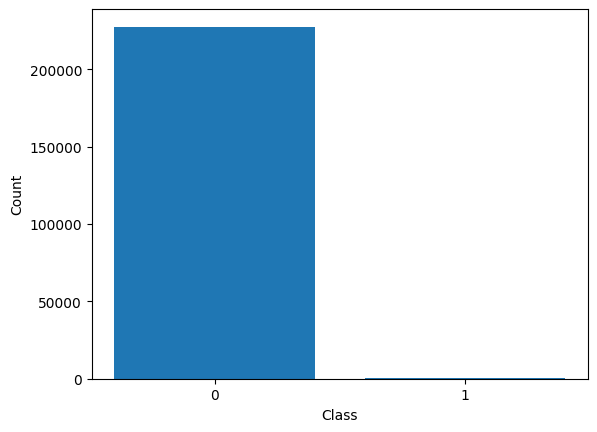

In [142]:
import matplotlib.pyplot as plt

counts = df["Class"].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Class")
plt.ylabel("Count")

counts

In [155]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

X = df.drop(columns=["id", "Time", "Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

preds = model.predict(X_test)
f1_score(y_test, preds)

1.0

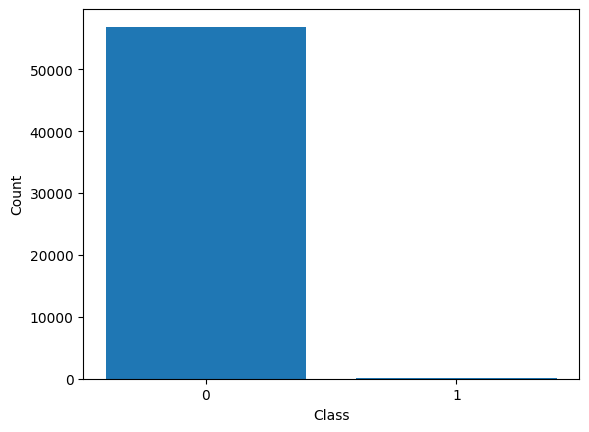

0    56884
1       78
Name: count, dtype: int64

In [156]:
test_preds = model.predict(test.drop(columns=["id", "Time"]))
test_out = pd.DataFrame({
    "subtaskID": 3,
    "datapointID": test["id"],
    "answer": test_preds.astype(int)
})

cnts = pd.Series(test_preds).value_counts().sort_index()

plt.bar(cnts.index.astype(str), cnts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

real_out = pd.concat([output, test_out], ignore_index=True)
real_out["subtaskID"] = real_out["subtaskID"].astype(int)

real_out["datapointID"] = real_out["datapointID"].astype(int)
real_out.to_csv("output.csv", index=False)

cnts